# Optimization of geometries formed via boolean clip operations

This notebook demonstrates how to use `tidy3d` autograd support with boolean `ClipOperation` geometries. We will optimize a finite GaN micro-LED light extractor whose top surface is etched by the intersection of two slightly different hexagonal hole lattices. The design parameters control the two lattice pitches, hole radii, and relative rotation. The relative lateral shift is fixed to zero to preserve the symmetry of the extractor.

Compared to a strictly periodic texture, this moire-style construction introduces a slowly varying superstructure and a broader set of spatial frequencies across the finite LED pixel. That extra geometric diversity can help scatter guided and high-angle emission into upward radiation, while the pattern is still described by only a few differentiable parameters and physically motivated boolean operations.

The objective is the upward flux through a `FieldMonitor` above the device. Because the objective is differentiable through the Tidy3D remote adjoint workflow, each optimization step uses one forward and one adjoint simulation to update all geometric parameters at once.

After optimization, we prototype a simple fabrication cleanup step that removes or closes features below a selected process threshold. We then compute normalized top light extraction efficiency (top LEE) using flux monitors: the upward extracted power is divided by the power emitted through a small flux box around the dipole. We compare the raw and fabrication-processed initial and optimized designs against a flat-interface reference, and then check polarization averaging and dipole-position averaging at twice the optimization mesh resolution.

<img src="./img/autograd32_microled_clip_thumbnail.png" width="500" alt="Schematic of a patterned micro-LED light extractor optimized with ClipOperation geometry.">

> Note: Running the complete notebook launches remote Tidy3D jobs. The optimization loop launches two simulations per iteration through the adjoint workflow, while the LEE and position-average sections launch additional non-adjoint simulations.

If you are new to inverse design in Tidy3D, start with [Inverse design overview](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Overview/), [Autograd quickstart level 1](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd0Quickstart/), and [Autograd basics](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd1Intro/). For a general introduction to LED LEE calculations, see [Light extraction efficiency calculation of a square-shaped micro-LED](https://www.flexcompute.com/tidy3d/examples/notebooks/LedLEECalculation/).

## Setup

We first import the libraries used for geometry construction, remote simulation, optimization, and visualization. The optimizer is Tidy3D's built-in Adam helper from `tidy3d.plugins.autograd`.


In [1]:
import autograd as ag
import autograd.numpy as anp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.autograd import adam, apply_updates

td.config.logging.level = "ERROR"

07:43:37 EDT WARNING: Using canonical configuration directory at                
             '/Users/gregoryroberts/.config/tidy3d'. Found legacy directory at  
             '/Users/gregoryroberts/.tidy3d', which will be ignored. Tidy3D     
             configuration now uses                                             
             '/Users/gregoryroberts/.config/tidy3d/config.toml'.                

Next we define the fixed physical parameters. Lengths are in microns.

In [2]:
air_index = 1.0
gan_index = 2.4

air_medium = td.Medium(permittivity=air_index**2)
gan_medium = td.Medium(permittivity=gan_index**2)

domain_size_xy = 4.5
pixel_size_xy = 3.5
pixel_half_width = pixel_size_xy / 2.0

gan_z_max = 0.5
etch_z_min = 0.3
etch_z_max = 0.5
etch_depth = etch_z_max - etch_z_min
etch_center_z = 0.5 * (etch_z_min + etch_z_max)

bottom_source_spacing = 0.5
structure_monitor_spacing = 0.4
monitor_top_spacing = 0.25

field_monitor_z = gan_z_max + structure_monitor_spacing
source_z = -field_monitor_z
domain_z_min = source_z - bottom_source_spacing
domain_z_max = field_monitor_z + monitor_top_spacing
domain_size_z = domain_z_max - domain_z_min
domain_center_z = 0.5 * (domain_z_min + domain_z_max)
domain_size = (domain_size_xy, domain_size_xy, domain_size_z)
domain_center = (0.0, 0.0, domain_center_z)
gan_z_min = domain_z_min
source_center = (0.0, 0.0, source_z)
source_norm_box_size = 0.4

center_wavelength = 0.5
bandwidth_wavelength = 0.1
wavelength_min = center_wavelength - bandwidth_wavelength / 2.0
wavelength_max = center_wavelength + bandwidth_wavelength / 2.0

freq0 = td.C_0 / center_wavelength
freq_min = td.C_0 / wavelength_max
freq_max = td.C_0 / wavelength_min
freq_width = freq_max - freq_min
monitor_freqs = np.array([freq0])

run_time = 200.0 / freq_width
min_steps_per_wvl = 15


The helper below lets us set separate mesh densities for optimization and final evaluation. The final non-adjoint LEE evaluations use twice the optimization mesh resolution.


In [3]:
def make_grid_spec(steps_per_wvl=min_steps_per_wvl):
    """Create the FDTD grid used by optimization or final analysis.

    Parameters
    ----------
    steps_per_wvl : float
        Minimum number of grid cells per free-space wavelength. The same value is also
        converted to a local mesh override around the patterned etch region.

    Returns
    -------
    td.GridSpec
        Automatic Tidy3D grid specification with a uniform refinement box around the
        small etched features.
    """
    dl = wavelength_min / steps_per_wvl
    grid_spec = td.GridSpec.auto(
        wavelength=center_wavelength,
        min_steps_per_wvl=steps_per_wvl,
        override_structures=[td.MeshOverrideStructure(
            geometry=td.Box.from_bounds(
                rmin=(-pixel_half_width - 0.5 * wavelength_min, -pixel_half_width - 0.5 * wavelength_min, etch_z_min - 0.5 * wavelength_min),
                rmax=(pixel_half_width + 0.5 * wavelength_min, pixel_half_width + 0.5 * wavelength_min, etch_z_max + 0.5 * wavelength_min),
            ),
            dl=(dl, dl, dl),
        )]
    )
    return grid_spec


optimization_steps_per_wvl = min_steps_per_wvl
analysis_steps_per_wvl = 2 * optimization_steps_per_wvl

grid_spec = make_grid_spec(optimization_steps_per_wvl)
analysis_grid_spec = make_grid_spec(analysis_steps_per_wvl)


## Design Parameterization

The design is described by five normalized parameters in `[0, 1]`. They map to two pitches, two radii, and one relative rotation angle. The lateral shift of the second lattice is fixed at zero to keep the pattern symmetric. We keep the number of lattice sites fixed during optimization so that the geometry changes smoothly as parameters move.


In [4]:
param_names = ("pitch_a", "pitch_b", "r_a", "r_b", "theta_deg")

pitch_min = 0.25
pitch_max = 0.60
radius_min = 0.05
radius_fraction_max = 0.40
theta_max_deg = 60.0
fixed_dx = 0.0
fixed_dy = 0.0

initial_physical_param_values = {
    "pitch_a": 0.45,
    "pitch_b": 0.50,
    "r_a": 0.10,
    "r_b": 0.15,
    "theta_deg": 21.8,
}
initial_physical_params = np.array(
    [initial_physical_param_values[name] for name in param_names],
    dtype=float,
)

sqrt3 = np.sqrt(3.0)


In [5]:
def build_fixed_lattice_index_window():
    """Return fixed integer indices for all candidate hexagonal lattice sites.

    The index window is intentionally larger than the pixel footprint so that all
    allowed pitches, rotations, and radii cover the device during optimization.

    Returns
    -------
    tuple[tuple[int, int], ...]
        Hexagonal lattice indices used for both lattices throughout the notebook.
    """
    cover_radius = np.sqrt(2.0) * pixel_half_width + 2.0 * pitch_max
    j_limit = int(np.ceil(cover_radius / ((sqrt3 / 2.0) * pitch_min))) + 2
    i_limit = int(np.ceil(cover_radius / pitch_min)) + 2

    return tuple(
        (i_idx, j_idx)
        for j_idx in range(-j_limit, j_limit + 1)
        for i_idx in range(-i_limit, i_limit + 1)
    )


fixed_lattice_index_pairs = build_fixed_lattice_index_window()


In [6]:
def pack_params_named(params):
    """Map normalized design variables to physical geometry parameters.

    Parameters
    ----------
    params : array-like of float
        Five normalized optimizer variables in the order given by `param_names`.

    Returns
    -------
    dict[str, float]
        Physical pitches, radii, rotation angle in degrees, and the fixed lateral
        shift values used by the geometry builder.
    """
    pitch_a = pitch_min + params[0] * (pitch_max - pitch_min)
    pitch_b = pitch_min + params[1] * (pitch_max - pitch_min)

    radius_a_max = radius_fraction_max * pitch_a
    radius_b_max = radius_fraction_max * pitch_b

    radius_a = radius_min + params[2] * (radius_a_max - radius_min)
    radius_b = radius_min + params[3] * (radius_b_max - radius_min)

    theta_deg = params[4] * theta_max_deg

    return {
        "pitch_a": pitch_a,
        "pitch_b": pitch_b,
        "r_a": radius_a,
        "r_b": radius_b,
        "theta_deg": theta_deg,
        "dx": fixed_dx,
        "dy": fixed_dy,
    }


def encode_initial_params(params):
    """Convert physical starting parameters into normalized optimizer variables.

    Parameters
    ----------
    params : array-like of float
        Physical values for `pitch_a`, `pitch_b`, `r_a`, `r_b`, and `theta_deg`.

    Returns
    -------
    np.ndarray
        Normalized parameter vector clipped to the optimizer interval `[0, 1]`.
    """
    pitch_a, pitch_b, radius_a, radius_b, theta_deg = np.asarray(params, dtype=float)
    normalized = np.empty(len(param_names), dtype=float)

    normalized[0] = (pitch_a - pitch_min) / (pitch_max - pitch_min)
    normalized[1] = (pitch_b - pitch_min) / (pitch_max - pitch_min)

    radius_a_max = radius_fraction_max * pitch_a
    radius_b_max = radius_fraction_max * pitch_b
    normalized[2] = (radius_a - radius_min) / (radius_a_max - radius_min)
    normalized[3] = (radius_b - radius_min) / (radius_b_max - radius_min)

    normalized[4] = theta_deg / theta_max_deg

    return np.clip(normalized, 0.0, 1.0)


def project_params(params):
    """Project optimizer variables back into the valid normalized box.

    Parameters
    ----------
    params : array-like of float
        Candidate normalized optimizer variables.

    Returns
    -------
    np.ndarray
        Clipped copy with every value in `[0, 1]`.
    """
    return np.clip(np.asarray(params, dtype=float).copy(), 0.0, 1.0)


def format_params(params):
    """Format normalized variables as readable physical parameter values.

    Parameters
    ----------
    params : array-like of float
        Normalized optimizer variables.

    Returns
    -------
    str
        Comma-separated physical parameter string for progress logging.
    """
    values = pack_params_named(np.asarray(params, dtype=float))
    return ", ".join(f"{name}={value:.4f}" for name, value in values.items())


## ClipOperation Geometry

We now build two hexagonal lattices of cylindrical air holes. The second lattice can be rotated relative to the first while its lateral shift remains fixed at zero. The final etched region is the intersection of the two lattices clipped to the finite square pixel footprint.

The `operation` variable is set to `"intersection"` for this notebook. Changing it to `"xor"` switches the two-lattice combination to a symmetric difference pattern.

One physical way to think about the intersection pattern is a double-exposure lithography process. A first exposure writes one hexagonal mask, a second slightly rotated exposure writes another, and only the regions that receive enough combined dose open the resist for etching. The resulting top etch is represented directly in Tidy3D by intersecting the two hole lattices with a `ClipOperation`.

<img src="./img/autograd32_microled_clip_process.png" width="700" alt="Schematic double exposure lithography process leading to an intersected air-hole etch pattern.">


In [7]:
operation = "intersection"


In [8]:
def lattice_center(pitch, i_idx, j_idx, theta_rad=0.0, dx=0.0, dy=0.0):
    """Compute the center of one rotated and shifted hexagonal lattice site.

    Parameters
    ----------
    pitch : float
        Hexagonal lattice pitch in microns.
    i_idx, j_idx : int
        Integer lattice coordinates.
    theta_rad : float
        In-plane rotation angle in radians.
    dx, dy : float
        Lateral translation in microns.

    Returns
    -------
    tuple[float, float]
        Differentiable x and y coordinates of the site center.
    """
    x_base = pitch * (i_idx + 0.5 * j_idx)
    y_base = pitch * (sqrt3 / 2.0) * j_idx

    cos_theta = anp.cos(theta_rad)
    sin_theta = anp.sin(theta_rad)
    x_rot = cos_theta * x_base - sin_theta * y_base
    y_rot = sin_theta * x_base + cos_theta * y_base
    return x_rot + dx, y_rot + dy


def build_hex_lattice_holes(pitch, radius, theta_rad=0.0, dx=0.0, dy=0.0):
    """Build one hexagonal lattice of cylindrical air holes.

    Parameters
    ----------
    pitch : float
        Hexagonal lattice pitch in microns.
    radius : float
        Radius of each cylindrical hole in microns.
    theta_rad : float
        In-plane lattice rotation in radians.
    dx, dy : float
        Lateral shift of the lattice in microns.

    Returns
    -------
    td.GeometryGroup
        Group of cylindrical hole geometries spanning the pixel footprint.
    """
    cylinders = []
    for i_idx, j_idx in fixed_lattice_index_pairs:
        x_pos, y_pos = lattice_center(
            pitch,
            i_idx,
            j_idx,
            theta_rad=theta_rad,
            dx=dx,
            dy=dy,
        )
        cylinders.append(
            td.Cylinder(
                center=(x_pos, y_pos, etch_center_z),
                radius=radius,
                length=etch_depth,
                axis=2,
            )
        )

    return td.GeometryGroup(geometries=tuple(cylinders))


def combine_lattices(lattice_a, lattice_b, operation):
    """Combine two hole lattices with a boolean `ClipOperation`.

    Parameters
    ----------
    lattice_a, lattice_b : td.Geometry
        Geometry operands representing the two hole lattices.
    operation : {"intersection", "xor"}
        Boolean operation used to form the etch pattern.

    Returns
    -------
    td.Geometry
        Boolean geometry that remains differentiable through Tidy3D autograd.
    """
    if operation == "intersection":
        return lattice_a & lattice_b
    if operation == "xor":
        return lattice_a ^ lattice_b
    raise ValueError(f"Unsupported operation: {operation!r}.")


def build_etch_geometry(params, operation=operation):
    """Create the full patterned air-etch geometry from design variables.

    Parameters
    ----------
    params : array-like of float
        Normalized optimizer variables.
    operation : str
        Boolean operation passed to `combine_lattices`.

    Returns
    -------
    td.Geometry
        Air-hole pattern clipped to the finite square pixel footprint.
    """
    named = pack_params_named(params)
    theta_rad = named["theta_deg"] * anp.pi / 180.0

    lattice_a = build_hex_lattice_holes(named["pitch_a"], named["r_a"])
    lattice_b = build_hex_lattice_holes(
        named["pitch_b"],
        named["r_b"],
        theta_rad=theta_rad,
        dx=named["dx"],
        dy=named["dy"],
    )

    raw_pattern = combine_lattices(lattice_a, lattice_b, operation=operation)
    pixel_mask = td.Box.from_bounds(
        rmin=(-pixel_half_width, -pixel_half_width, etch_z_min),
        rmax=(pixel_half_width, pixel_half_width, etch_z_max),
    )

    return raw_pattern & pixel_mask


def build_static_gan_structures():
    """Create the GaN structures that do not depend on optimization variables.

    Returns
    -------
    tuple[td.Structure, td.Structure]
        Lower GaN block and upper GaN cap surrounding the etched air region.
    """
    lower_gan = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-pixel_half_width, -pixel_half_width, gan_z_min),
            rmax=(pixel_half_width, pixel_half_width, etch_z_min),
        ),
        medium=gan_medium,
        name="gan_lower",
    )

    upper_gan_cap = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-pixel_half_width, -pixel_half_width, etch_z_min),
            rmax=(pixel_half_width, pixel_half_width, etch_z_max),
        ),
        medium=gan_medium,
        name="gan_cap",
    )

    return lower_gan, upper_gan_cap


def build_traced_etch_structure(etch_geometry):
    """Wrap an air-etch geometry as a Tidy3D structure inside GaN.

    Parameters
    ----------
    etch_geometry : td.Geometry
        Air-hole geometry, either raw `ClipOperation` output or processed `PolySlab` geometry.

    Returns
    -------
    td.Structure
        Air structure with GaN as its background medium.
    """
    return td.Structure(
        geometry=etch_geometry,
        medium=air_medium,
        background_medium=gan_medium,
        name="etch_holes",
    )


def build_interface_reference_structure():
    """Create the flat GaN-to-air reference structure.

    Returns
    -------
    td.Structure
        Unpatterned GaN block used as the baseline LEE comparison.
    """
    return td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-0.5 * domain_size[0], -0.5 * domain_size[1], gan_z_min),
            rmax=(0.5 * domain_size[0], 0.5 * domain_size[1], gan_z_max),
        ),
        medium=gan_medium,
        name="gan_interface_reference",
    )


## Simulation Helpers

The optimization simulation uses a `FieldMonitor` above the device, which is compatible with adjoint differentiation. The LEE analysis simulations use flux monitors: a top monitor and a small closed flux box around the dipole for source-power normalization.

In [9]:
def make_source(source_center=source_center, polarization="Ex"):
    """Create the point-dipole source used for optimization and analysis.

    Parameters
    ----------
    source_center : tuple[float, float, float]
        Dipole position in microns.
    polarization : str
        Tidy3D point-dipole polarization, such as `"Ex"` or `"Ey"`.

    Returns
    -------
    td.PointDipole
        Broadband dipole source centered at `freq0`.
    """
    return td.PointDipole(
        center=source_center,
        polarization=polarization,
        source_time=td.GaussianPulse(
            freq0=freq0,
            fwidth=freq_width,
            amplitude=1.0,
        ),
    )


def make_field_monitor():
    """Create the differentiable top field monitor for the adjoint objective.

    Returns
    -------
    td.FieldMonitor
        Planar monitor above the pixel that records fields and supports flux evaluation.
    """
    return td.FieldMonitor(
        center=(0.0, 0.0, field_monitor_z),
        size=(domain_size[0], domain_size[1], 0.0),
        freqs=tuple(monitor_freqs.tolist()),
        name="top_fields",
    )


def make_top_flux_monitor():
    """Create the upward flux monitor used for top LEE analysis.

    Returns
    -------
    td.FluxMonitor
        Planar flux monitor above the pixel with positive z normal direction.
    """
    return td.FluxMonitor(
        center=(0.0, 0.0, field_monitor_z),
        size=(domain_size[0], domain_size[1], 0.0),
        freqs=tuple(monitor_freqs.tolist()),
        name="top_flux_monitor",
        normal_dir="+",
    )


def make_norm_flux_monitor(source_center=source_center):
    """Create the small flux box used to estimate emitted dipole power.

    Parameters
    ----------
    source_center : tuple[float, float, float]
        Center of the normalization box, matching the dipole position.

    Returns
    -------
    td.FluxMonitor
        Closed flux-box monitor around the source.
    """
    return td.FluxMonitor(
        center=source_center,
        size=(source_norm_box_size, source_norm_box_size, source_norm_box_size),
        freqs=tuple(monitor_freqs.tolist()),
        name="norm_flux_monitor",
    )


In [10]:
def build_simulation(
    params,
    operation=operation,
    monitors=None,
    source_center=source_center,
    source_polarization="Ex",
    grid_spec=grid_spec,
    etch_geometry=None,
):
    """Build a patterned micro-LED simulation.

    Parameters
    ----------
    params : array-like of float
        Normalized optimizer variables used when `etch_geometry` is not supplied.
    operation : str
        Boolean operation for the raw `ClipOperation` etch geometry.
    monitors : tuple[td.Monitor, ...] or None
        Monitors to include. Defaults to the adjoint field monitor.
    source_center : tuple[float, float, float]
        Dipole position in microns.
    source_polarization : str
        Dipole polarization passed to `make_source`.
    grid_spec : td.GridSpec
        Mesh specification for the simulation.
    etch_geometry : td.Geometry or None
        Optional prebuilt etch geometry, used for fabrication-processed analysis.

    Returns
    -------
    td.Simulation
        Fully assembled simulation with GaN, air holes, source, monitors, PML, and mesh.
    """
    if etch_geometry is None:
        etch_geometry = build_etch_geometry(params, operation=operation)

    structures = (
        *build_static_gan_structures(),
        build_traced_etch_structure(etch_geometry),
    )

    return td.Simulation(
        center=domain_center,
        size=domain_size,
        medium=air_medium,
        structures=structures,
        sources=(make_source(source_center=source_center, polarization=source_polarization),),
        monitors=monitors or (make_field_monitor(),),
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=True),
        grid_spec=grid_spec,
        run_time=run_time,
    )


def build_optimization_simulation(
    params,
    operation=operation,
    source_center=source_center,
    source_polarization="Ex",
    grid_spec=grid_spec,
):
    """Build the differentiable simulation used inside the adjoint objective.

    Parameters
    ----------
    params : array-like of float
        Normalized optimizer variables.
    operation : str
        Boolean operation for the etch geometry.
    source_center : tuple[float, float, float]
        Dipole position in microns.
    source_polarization : str
        Dipole polarization.
    grid_spec : td.GridSpec
        Mesh specification.

    Returns
    -------
    td.Simulation
        Simulation containing only the field monitor required by the objective.
    """
    return build_simulation(
        params,
        operation=operation,
        monitors=(make_field_monitor(),),
        source_center=source_center,
        source_polarization=source_polarization,
        grid_spec=grid_spec,
    )


def build_analysis_simulation(
    params,
    operation=operation,
    source_center=source_center,
    source_polarization="Ex",
    grid_spec=grid_spec,
    etch_geometry=None,
):
    """Build a non-adjoint simulation for normalized top LEE evaluation.

    Parameters
    ----------
    params : array-like of float
        Normalized optimizer variables used when no explicit `etch_geometry` is supplied.
    operation : str
        Boolean operation for the raw etch geometry.
    source_center : tuple[float, float, float]
        Dipole position in microns.
    source_polarization : str
        Dipole polarization.
    grid_spec : td.GridSpec
        Mesh specification, usually `analysis_grid_spec`.
    etch_geometry : td.Geometry or None
        Optional processed etch geometry to evaluate instead of the raw clip geometry.

    Returns
    -------
    td.Simulation
        Simulation containing top and source-normalization flux monitors.
    """
    monitors = [
        make_top_flux_monitor(),
        make_norm_flux_monitor(source_center=source_center),
    ]

    return build_simulation(
        params,
        operation=operation,
        monitors=tuple(monitors),
        source_center=source_center,
        source_polarization=source_polarization,
        grid_spec=grid_spec,
        etch_geometry=etch_geometry,
    )


def build_interface_reference_simulation(
    source_center=source_center,
    source_polarization="Ex",
    grid_spec=grid_spec,
):
    """Build the unpatterned flat-interface reference simulation.

    Parameters
    ----------
    source_center : tuple[float, float, float]
        Dipole position in microns.
    source_polarization : str
        Dipole polarization.
    grid_spec : td.GridSpec
        Mesh specification for the reference run.

    Returns
    -------
    td.Simulation
        Flat GaN-to-air simulation with the same source and LEE monitors.
    """
    return td.Simulation(
        center=domain_center,
        size=domain_size,
        medium=air_medium,
        structures=(build_interface_reference_structure(),),
        sources=(make_source(source_center=source_center, polarization=source_polarization),),
        monitors=(
            make_top_flux_monitor(),
            make_norm_flux_monitor(source_center=source_center),
        ),
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=True),
        grid_spec=grid_spec,
        run_time=run_time,
    )


We construct and validate the initial simulation locally before launching any remote jobs.

In [11]:
params0 = project_params(encode_initial_params(initial_physical_params))
sim0 = build_optimization_simulation(params0)
sim0.validate_pre_upload()

print(format_params(params0))

pitch_a=0.4500, pitch_b=0.5000, r_a=0.1000, r_b=0.1500, theta_deg=21.8000, dx=0.0000, dy=0.0000


Now we inspect the starting geometry in top and side views.

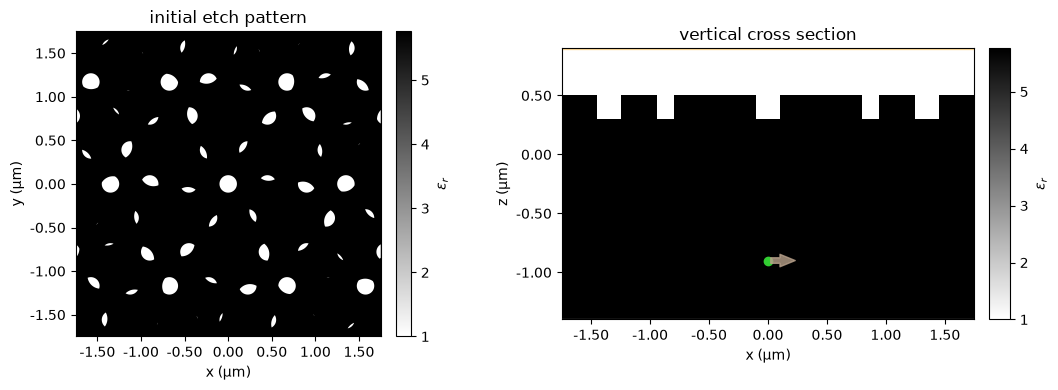

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), tight_layout=True)

sim0.plot_eps(z=etch_center_z, ax=ax[0])
ax[0].set_xlim(-pixel_half_width, pixel_half_width)
ax[0].set_ylim(-pixel_half_width, pixel_half_width)
ax[0].set_aspect("equal")
ax[0].set_title("initial etch pattern")

sim0.plot_eps(y=0, ax=ax[1])
ax[1].set_xlim(-pixel_half_width, pixel_half_width)
ax[1].set_ylim(gan_z_min, field_monitor_z)
ax[1].set_title("vertical cross section")

plt.show()

## Adjoint Objective

Our figure of merit is the frequency-averaged upward flux through the top `FieldMonitor`. The objective returns a scalar so `autograd.value_and_grad` can differentiate it with respect to the five design parameters.

In [13]:
def objective(params, task_name="autograd32_clip_operation", verbose=False):
    """Evaluate the scalar adjoint objective for a candidate design.

    Parameters
    ----------
    params : array-like of float
        Normalized optimizer variables.
    task_name : str
        Name assigned to the remote Tidy3D task.
    verbose : bool
        Whether to print remote run progress.

    Returns
    -------
    autograd.numpy scalar
        Frequency-averaged upward flux through the top field monitor.
    """
    sim = build_optimization_simulation(params, operation=operation)
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    return anp.mean(sim_data["top_fields"].flux.values)


value_and_grad = ag.value_and_grad(objective)


## Optimization

We now run Adam using `tidy3d.plugins.autograd.adam`. Adam minimizes by default, so we pass the negative gradient to maximize the upward extracted flux.

In [14]:
num_steps = 60
learning_rate = 0.01
print_every = 5

params = np.array(params0)
optimizer = adam(learning_rate=learning_rate)
opt_state = optimizer.init(params)

objective_history = []
gradient_norm_history = []
params_history = [params.copy()]
physical_params_history = [pack_params_named(params)]

In [15]:
for step_index in range(num_steps):
    task_name = f"autograd32-clip-operation-iter-{step_index:02d}"

    def step_objective(current_params):
        return objective(current_params, task_name=task_name, verbose=False)

    value, gradient = ag.value_and_grad(step_objective)(params)
    gradient = np.asarray(gradient, dtype=float)
    gradient_norm = np.linalg.norm(gradient)

    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params = project_params(apply_updates(params, updates))

    objective_history.append(float(value))
    gradient_norm_history.append(float(gradient_norm))
    params_history.append(params.copy())
    physical_params_history.append(pack_params_named(params))

    if step_index == 0 or (step_index + 1) % print_every == 0 or step_index == num_steps - 1:
        print(f"step = {step_index + 1:02d}")
        print(f"  objective = {value:.4e}")
        print(f"  grad_norm = {gradient_norm:.4e}")
        print(f"  {format_params(params)}")

params_final = params.copy()

step = 01
  objective = 2.5856e+02
  grad_norm = 9.6830e+01
  pitch_a=0.4465, pitch_b=0.4965, r_a=0.1007, r_b=0.1506, theta_deg=22.4000, dx=0.0000, dy=0.0000
step = 05
  objective = 2.6252e+02
  grad_norm = 7.0101e+01
  pitch_a=0.4474, pitch_b=0.4911, r_a=0.1060, r_b=0.1549, theta_deg=22.1306, dx=0.0000, dy=0.0000
step = 10
  objective = 2.6649e+02
  grad_norm = 3.7942e+01
  pitch_a=0.4446, pitch_b=0.4951, r_a=0.1118, r_b=0.1633, theta_deg=22.7500, dx=0.0000, dy=0.0000
step = 15
  objective = 2.7089e+02
  grad_norm = 9.5962e+01
  pitch_a=0.4481, pitch_b=0.4920, r_a=0.1188, r_b=0.1696, theta_deg=24.6987, dx=0.0000, dy=0.0000
step = 20
  objective = 2.7316e+02
  grad_norm = 6.8473e+01
  pitch_a=0.4525, pitch_b=0.4830, r_a=0.1258, r_b=0.1736, theta_deg=26.1770, dx=0.0000, dy=0.0000
step = 25
  objective = 2.7672e+02
  grad_norm = 9.4411e+01
  pitch_a=0.4493, pitch_b=0.4731, r_a=0.1321, r_b=0.1755, theta_deg=26.9548, dx=0.0000, dy=0.0000
step = 30
  objective = 2.7835e+02
  grad_norm = 1.5

The next plots summarize the optimization and compare the initial and final patterns.

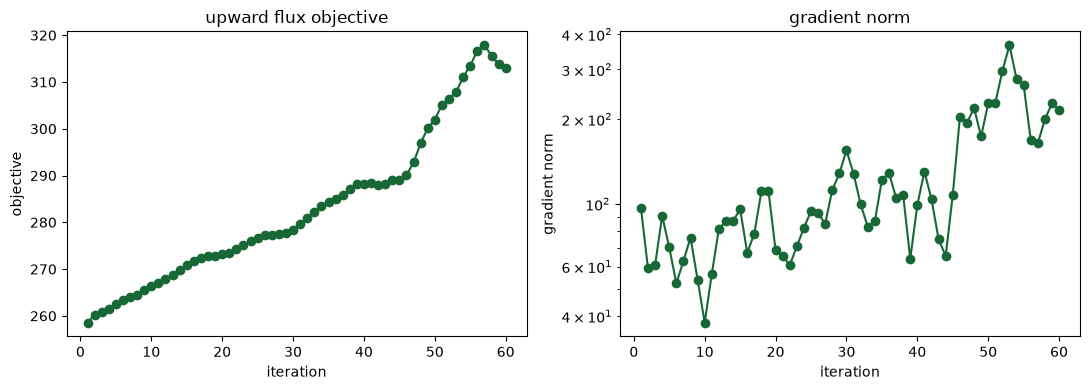

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), tight_layout=True)

ax[0].plot(np.arange(1, num_steps + 1), objective_history, "o-")
ax[0].set_xlabel("iteration")
ax[0].set_ylabel("objective")
ax[0].set_title("upward flux objective")

ax[1].semilogy(np.arange(1, num_steps + 1), gradient_norm_history, "o-")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("gradient norm")
ax[1].set_title("gradient norm")

plt.show()

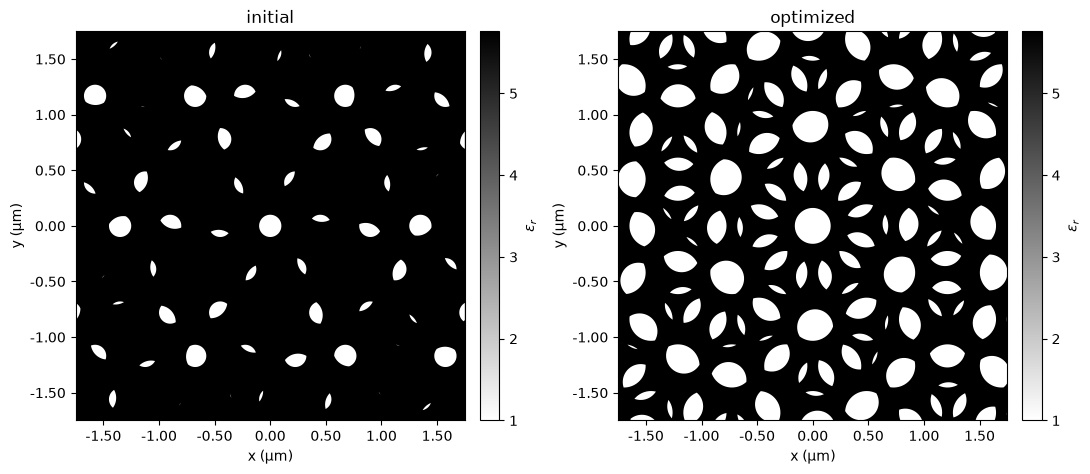

In [17]:
sim_final = build_optimization_simulation(params_final)

fig, ax = plt.subplots(1, 2, figsize=(11, 5), tight_layout=True)

sim0.plot_eps(z=etch_center_z, ax=ax[0])
ax[0].set_xlim(-pixel_half_width, pixel_half_width)
ax[0].set_ylim(-pixel_half_width, pixel_half_width)
ax[0].set_aspect("equal")
ax[0].set_title("initial")

sim_final.plot_eps(z=etch_center_z, ax=ax[1])
ax[1].set_xlim(-pixel_half_width, pixel_half_width)
ax[1].set_ylim(-pixel_half_width, pixel_half_width)
ax[1].set_aspect("equal")
ax[1].set_title("optimized")

plt.show()

In [18]:
pd.DataFrame(
    [
        {"design": "initial", **pack_params_named(params0)},
        {"design": "optimized", **pack_params_named(params_final)},
    ]
).round(4)

,design,pitch_a,pitch_b,r_a,r_b,theta_deg,dx,dy
0,initial,0.4500,0.5000,0.1000,0.1500,21.8000,0.0,0.0
1,optimized,0.4847,0.4559,0.1939,0.1612,31.3357,0.0,0.0


## Fabrication Cleanup Prototype

The raw adjoint result may contain tiny etched islands, thin bridges, or narrow unetched gaps. Those features can be numerically meaningful in the boolean geometry, but they may not survive a real lithography and etch process. Here we prototype a simple cleanup for both the initial and optimized designs: convert each `ClipOperation` slice to Shapely polygons, apply a minimum-feature rule, then convert the cleaned polygons back into `PolySlab` geometry for final evaluation.

This cleanup is not a differentiable operation as written, so we do not include it directly in the optimization. It is meant to model what may happen in practice when applying this fabrication technique. By evaluating both raw and postprocessed designs, we check that the optimized result does not depend on tiny features produced by the raw boolean geometry, and instead reflects the larger-scale pattern found by the optimizer.


In [19]:
import shapely


minimum_fabrication_feature = 0.05
fabrication_cleanup_mode = "open_close"
use_cleaned_design_for_analysis = True


def _as_multipolygon(shapely_geometry):
    """Normalize a Shapely object into a valid `MultiPolygon`.

    Parameters
    ----------
    shapely_geometry : shapely.Geometry
        Shapely geometry returned by boolean or cleanup operations.

    Returns
    -------
    shapely.MultiPolygon
        Valid polygons with points, lines, and empty geometries removed.
    """
    valid_geometry = shapely.make_valid(shapely_geometry)
    polygons = td.ClipOperation.to_polygon_list(valid_geometry, cleanup=False)
    return shapely.MultiPolygon(polygons)


def etch_geometry_to_multipolygon(etch_geometry, cleanup=False, quad_segs=24):
    """Extract the 2D etch cross section from a Tidy3D geometry.

    Parameters
    ----------
    etch_geometry : td.Geometry
        Three-dimensional etch geometry to slice at `etch_center_z`.
    cleanup : bool
        Whether Tidy3D should apply its display-oriented polygon cleanup while slicing.
    quad_segs : int
        Number of line segments per circle quadrant used when slicing cylinders.

    Returns
    -------
    shapely.MultiPolygon
        Union of the etch polygons in the top-view plane.
    """
    polygons = etch_geometry.intersections_plane(
        z=etch_center_z,
        cleanup=cleanup,
        quad_segs=quad_segs,
    )
    if len(polygons) == 0:
        return shapely.MultiPolygon([])

    section = shapely.union_all([td.Geometry.evaluate_inf_shape(poly) for poly in polygons])
    return _as_multipolygon(section)


def _filter_small_components(multipolygon, minimum_feature):
    """Remove disconnected etched components below an equivalent-diameter threshold.

    Parameters
    ----------
    multipolygon : shapely.MultiPolygon
        Candidate etch regions.
    minimum_feature : float
        Minimum equivalent circular diameter in microns.

    Returns
    -------
    shapely.MultiPolygon
        Etch regions with small isolated components removed.
    """
    minimum_area = np.pi * (0.5 * minimum_feature) ** 2
    polygons = [
        polygon
        for polygon in td.ClipOperation.to_polygon_list(multipolygon, cleanup=False)
        if polygon.area >= minimum_area
    ]
    return shapely.MultiPolygon(polygons)


def clean_etch_multipolygon(multipolygon, minimum_feature, mode="open_close"):
    """Apply a simple fabrication cleanup to a 2D etch pattern.

    Parameters
    ----------
    multipolygon : shapely.MultiPolygon
        Raw etch regions.
    minimum_feature : float
        Process threshold in microns used as the diameter for area filtering and twice
        the radius for morphological opening or closing.
    mode : {"area_only", "open", "close", "open_close"}
        Cleanup operation. Opening removes small etched regions or necks; closing fills
        small unetched gaps; `open_close` applies both.

    Returns
    -------
    shapely.MultiPolygon
        Fabrication-processed etch regions.
    """
    radius = 0.5 * minimum_feature
    cleaned = _as_multipolygon(multipolygon)

    if mode in ("area", "area_only"):
        cleaned = _filter_small_components(cleaned, minimum_feature)
    elif mode in ("open", "remove_small_etch"):
        cleaned = cleaned.buffer(-radius, quad_segs=8).buffer(radius, quad_segs=8)
        cleaned = _filter_small_components(_as_multipolygon(cleaned), minimum_feature)
    elif mode in ("close", "fill_small_gaps"):
        cleaned = cleaned.buffer(radius, quad_segs=8).buffer(-radius, quad_segs=8)
        cleaned = _filter_small_components(_as_multipolygon(cleaned), minimum_feature)
    elif mode in ("open_close", "fabrication"):
        cleaned = cleaned.buffer(-radius, quad_segs=8).buffer(radius, quad_segs=8)
        cleaned = cleaned.buffer(radius, quad_segs=8).buffer(-radius, quad_segs=8)
        cleaned = _filter_small_components(_as_multipolygon(cleaned), minimum_feature)
    else:
        raise ValueError(f"Unsupported cleanup mode: {mode!r}.")

    return _as_multipolygon(cleaned)


def _ring_vertices(ring):
    """Convert a Shapely linear ring to Tidy3D polygon vertices.

    Parameters
    ----------
    ring : shapely.LinearRing
        Exterior or interior polygon ring.

    Returns
    -------
    list[tuple[float, float]]
        Ring vertices without the duplicated closing point.
    """
    x_coords, y_coords = ring.coords.xy
    return list(zip(np.asarray(x_coords[:-1]), np.asarray(y_coords[:-1])))


def polygon_to_polyslab(polygon):
    """Convert one Shapely polygon into a Tidy3D `PolySlab` geometry.

    Parameters
    ----------
    polygon : shapely.Polygon
        Processed etch polygon. Interior rings are represented as subtracted slabs.

    Returns
    -------
    td.Geometry
        `PolySlab` for a simple polygon, or a difference geometry when holes are present.
    """
    exterior = td.PolySlab(
        vertices=_ring_vertices(polygon.exterior),
        slab_bounds=(etch_z_min, etch_z_max),
        axis=2,
    )

    if len(polygon.interiors) == 0:
        return exterior

    interiors = tuple(
        td.PolySlab(
            vertices=_ring_vertices(interior),
            slab_bounds=(etch_z_min, etch_z_max),
            axis=2,
        )
        for interior in polygon.interiors
        if len(interior.coords) >= 4
    )

    if not interiors:
        return exterior

    return exterior - td.GeometryGroup(geometries=interiors)


def multipolygon_to_etch_geometry(multipolygon):
    """Convert processed Shapely etch regions back to Tidy3D geometry.

    Parameters
    ----------
    multipolygon : shapely.MultiPolygon
        Fabrication-processed etch regions in the top-view plane.

    Returns
    -------
    td.Geometry
        `PolySlab` or `GeometryGroup` suitable for use as the air-etch structure.
    """
    polygons = [
        polygon
        for polygon in td.ClipOperation.to_polygon_list(multipolygon, cleanup=False)
        if not polygon.is_empty and polygon.area > 0.0
    ]
    if len(polygons) == 0:
        raise ValueError("The fabrication cleanup removed every etched feature.")

    polyslabs = tuple(polygon_to_polyslab(polygon) for polygon in polygons)
    if len(polyslabs) == 1:
        return polyslabs[0]
    return td.GeometryGroup(geometries=polyslabs)


def summarize_multipolygon(multipolygon, label):
    """Summarize component count and equivalent feature sizes.

    Parameters
    ----------
    multipolygon : shapely.MultiPolygon
        Etch regions to summarize.
    label : str
        Label used in the output table.

    Returns
    -------
    dict[str, float | str]
        Geometry label, component count, total area, and representative equivalent diameters.
    """
    polygons = td.ClipOperation.to_polygon_list(multipolygon, cleanup=False)
    areas = np.asarray([polygon.area for polygon in polygons], dtype=float)
    equivalent_diameters = 2.0 * np.sqrt(areas / np.pi) if len(areas) else np.array([])

    return {
        "geometry": label,
        "num_components": len(polygons),
        "total_area_um2": float(np.sum(areas)) if len(areas) else 0.0,
        "min_equiv_diameter_um": float(np.min(equivalent_diameters)) if len(areas) else np.nan,
        "median_equiv_diameter_um": float(np.median(equivalent_diameters)) if len(areas) else np.nan,
    }


raw_etch_multipolygons = {
    "initial": etch_geometry_to_multipolygon(
        build_etch_geometry(params0, operation=operation),
        cleanup=False,
    ),
    "optimized": etch_geometry_to_multipolygon(
        build_etch_geometry(params_final, operation=operation),
        cleanup=False,
    ),
}
cleanup_modes = ("area_only", "open", "close", "open_close")
cleanup_candidates = {
    design: {
        mode: clean_etch_multipolygon(
            raw_etch,
            minimum_fabrication_feature,
            mode=mode,
        )
        for mode in cleanup_modes
    }
    for design, raw_etch in raw_etch_multipolygons.items()
}
cleaned_etch_multipolygons = {
    design: candidates[fabrication_cleanup_mode]
    for design, candidates in cleanup_candidates.items()
}
cleaned_etch_geometries = {
    design: multipolygon_to_etch_geometry(cleaned_etch)
    for design, cleaned_etch in cleaned_etch_multipolygons.items()
}

raw_initial_etch = raw_etch_multipolygons["initial"]
raw_optimized_etch = raw_etch_multipolygons["optimized"]
cleaned_initial_etch_multipolygon = cleaned_etch_multipolygons["initial"]
cleaned_optimized_etch_multipolygon = cleaned_etch_multipolygons["optimized"]
cleaned_initial_etch_geometry = cleaned_etch_geometries["initial"]
cleaned_optimized_etch_geometry = cleaned_etch_geometries["optimized"]
cleaned_etch_multipolygon = cleaned_optimized_etch_multipolygon
cleaned_etch_geometry = cleaned_optimized_etch_geometry

cleanup_summary_records = []
for design, raw_etch in raw_etch_multipolygons.items():
    record = summarize_multipolygon(raw_etch, "raw")
    record["design"] = design
    cleanup_summary_records.append(record)
    for mode in cleanup_modes:
        record = summarize_multipolygon(cleanup_candidates[design][mode], mode)
        record["design"] = design
        cleanup_summary_records.append(record)

cleanup_summary = pd.DataFrame(cleanup_summary_records)[
    [
        "design",
        "geometry",
        "num_components",
        "total_area_um2",
        "min_equiv_diameter_um",
        "median_equiv_diameter_um",
    ]
]
cleanup_summary.round(4)


,design,geometry,num_components,total_area_um2,min_equiv_diameter_um,median_equiv_diameter_um
0,initial,raw,65,0.6447,0.0063,0.0876
1,initial,area_only,47,0.6317,0.0751,0.0954
2,initial,open,43,0.5762,0.0578,0.1183
3,initial,close,47,0.6317,0.0751,0.0954
4,initial,open_close,43,0.5761,0.0577,0.1183
5,optimized,raw,135,3.3001,0.0118,0.1492
6,optimized,area_only,121,3.2824,0.0523,0.1657
7,optimized,open,99,3.1309,0.0593,0.1805
8,optimized,close,121,3.2823,0.0523,0.1657
9,optimized,open_close,99,3.1307,0.0593,0.1805


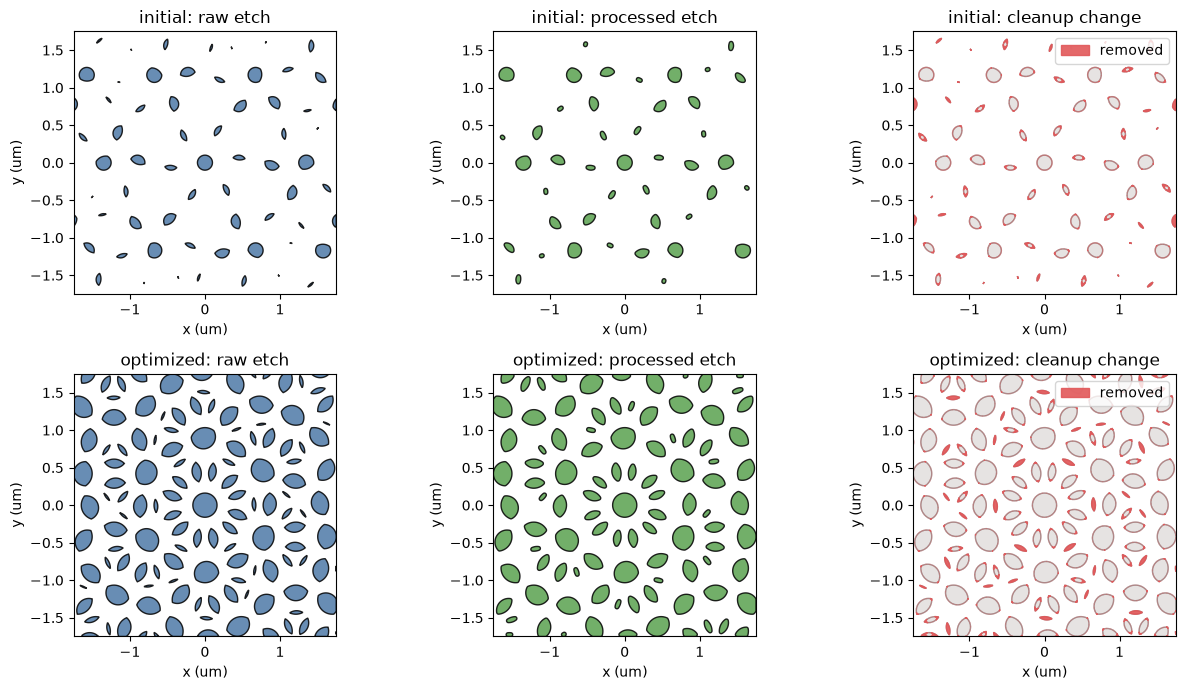

In [20]:
def plot_shapely_geometry(ax, geometry, facecolor, edgecolor="black", alpha=0.8, label=None):
    """Draw a Shapely polygon or multipolygon on a Matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis receiving the filled polygon patches.
    geometry : shapely.Geometry
        Polygonal geometry to plot.
    facecolor, edgecolor : str
        Matplotlib colors for polygon interiors and boundaries.
    alpha : float
        Fill transparency.
    label : str or None
        Optional legend label assigned to the first plotted component.

    Returns
    -------
    None
        The Matplotlib axis is modified in place.
    """
    for polygon in td.ClipOperation.to_polygon_list(geometry, cleanup=False):
        x_coords, y_coords = polygon.exterior.xy
        ax.fill(x_coords, y_coords, facecolor=facecolor, edgecolor=edgecolor, alpha=alpha, label=label)
        label = None
        for interior in polygon.interiors:
            x_hole, y_hole = interior.xy
            ax.fill(x_hole, y_hole, facecolor="white", edgecolor=edgecolor, alpha=1.0)


def plot_cleanup_comparison(axes, design, raw_etch, processed_etch):
    """Plot raw, processed, and changed etch regions for one design.

    Parameters
    ----------
    axes : array-like of matplotlib.axes.Axes
        Three axes used for the raw, processed, and changed geometries.
    design : str
        Design label shown in subplot titles.
    raw_etch : shapely.MultiPolygon
        Raw etch regions before fabrication cleanup.
    processed_etch : shapely.MultiPolygon
        Etch regions after fabrication cleanup.

    Returns
    -------
    None
        The Matplotlib axes are modified in place.
    """
    removed_etch = _as_multipolygon(raw_etch.difference(processed_etch))
    added_etch = _as_multipolygon(processed_etch.difference(raw_etch))

    plot_shapely_geometry(axes[0], raw_etch, facecolor="#4e79a7", alpha=0.85)
    axes[0].set_title(f"{design}: raw etch")

    plot_shapely_geometry(axes[1], processed_etch, facecolor="#59a14f", alpha=0.85)
    axes[1].set_title(f"{design}: processed etch")

    plot_shapely_geometry(axes[2], raw_etch, facecolor="#bab0ac", alpha=0.35)
    plot_shapely_geometry(axes[2], removed_etch, facecolor="#e15759", edgecolor="#e15759", alpha=0.9, label="removed")
    plot_shapely_geometry(axes[2], added_etch, facecolor="#4e79a7", edgecolor="#4e79a7", alpha=0.9, label="filled")
    axes[2].set_title(f"{design}: cleanup change")
    axes[2].legend(loc="upper right")


fig, ax = plt.subplots(2, 3, figsize=(13, 7), tight_layout=True)

plot_cleanup_comparison(
    ax[0],
    "initial",
    raw_initial_etch,
    cleaned_initial_etch_multipolygon,
)
plot_cleanup_comparison(
    ax[1],
    "optimized",
    raw_optimized_etch,
    cleaned_optimized_etch_multipolygon,
)

for axis in ax.ravel():
    axis.set_xlim(-pixel_half_width, pixel_half_width)
    axis.set_ylim(-pixel_half_width, pixel_half_width)
    axis.set_aspect("equal")
    axis.set_xlabel("x (um)")
    axis.set_ylabel("y (um)")

plt.show()


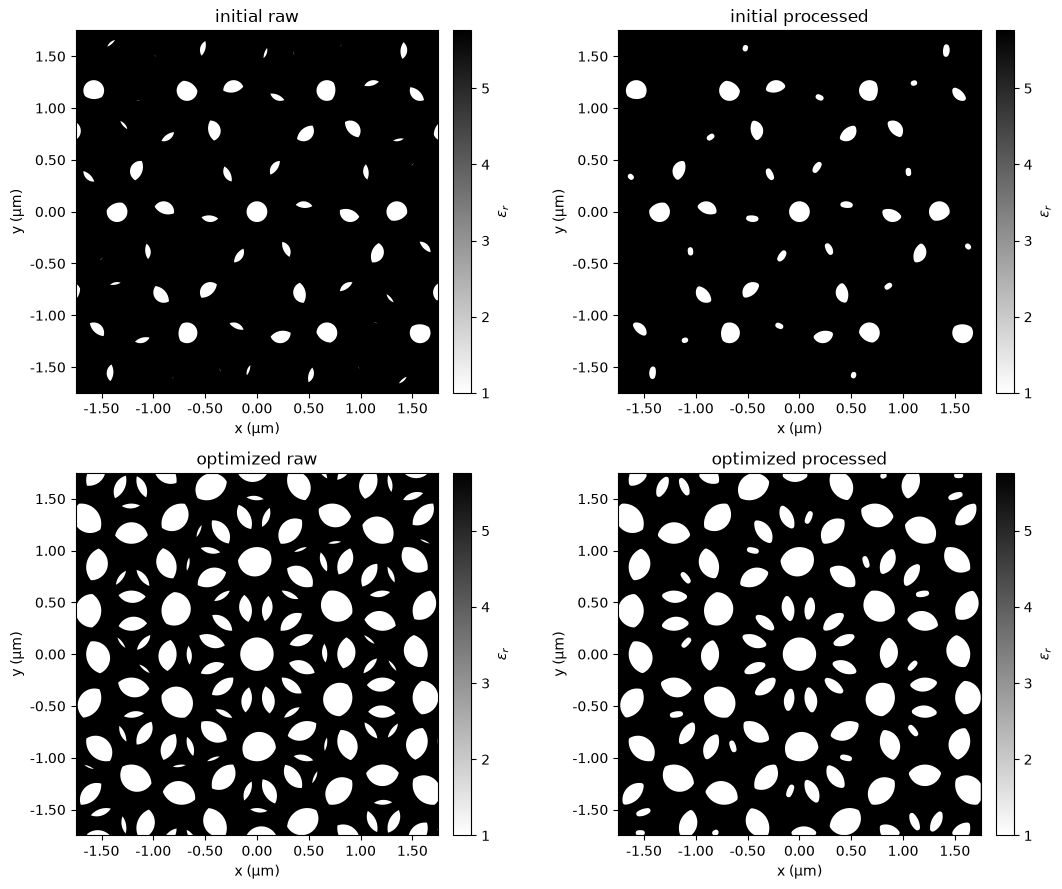

In [21]:
initial_processed_sim = build_analysis_simulation(
    params0,
    grid_spec=analysis_grid_spec,
    etch_geometry=cleaned_initial_etch_geometry,
)
optimized_processed_sim = build_analysis_simulation(
    params_final,
    grid_spec=analysis_grid_spec,
    etch_geometry=cleaned_optimized_etch_geometry,
)
initial_processed_sim.validate_pre_upload()
optimized_processed_sim.validate_pre_upload()

initial_raw_sim = build_analysis_simulation(params0, grid_spec=analysis_grid_spec)
optimized_raw_sim = build_analysis_simulation(params_final, grid_spec=analysis_grid_spec)

fig, ax = plt.subplots(2, 2, figsize=(11, 9), tight_layout=True)

initial_raw_sim.plot_eps(z=etch_center_z, ax=ax[0, 0])
ax[0, 0].set_title("initial raw")

initial_processed_sim.plot_eps(z=etch_center_z, ax=ax[0, 1])
ax[0, 1].set_title("initial processed")

optimized_raw_sim.plot_eps(z=etch_center_z, ax=ax[1, 0])
ax[1, 0].set_title("optimized raw")

optimized_processed_sim.plot_eps(z=etch_center_z, ax=ax[1, 1])
ax[1, 1].set_title("optimized processed")

for axis in ax.ravel():
    axis.set_xlim(-pixel_half_width, pixel_half_width)
    axis.set_ylim(-pixel_half_width, pixel_half_width)
    axis.set_aspect("equal")

plt.show()


## LEE Analysis

The optimization objective is an unnormalized upward flux. For the final performance analysis, we normalize by the dipole power estimated by a small closed flux box around the source.

We use only top LEE for the comparisons below. All final LEE simulations use `analysis_grid_spec`, which is set to twice the mesh resolution used during optimization. When `use_cleaned_design_for_analysis` is `True`, fabrication-processed versions of both the initial and optimized designs are included as additional comparisons. This avoids mixing the finite-pixel sidewall flux with the flat-interface reference, where lateral flux does not represent useful extraction from a finite LED sidewall.


In [22]:
def calculate_top_lee(sim_data):
    """Compute top light extraction efficiency from analysis simulation data.

    Parameters
    ----------
    sim_data : td.SimulationData
        Completed simulation containing `top_flux_monitor` and `norm_flux_monitor`.

    Returns
    -------
    tuple[np.ndarray, float]
        Frequency-resolved top LEE spectrum and its average over monitored frequencies.
    """
    emitted_flux = np.asarray(sim_data["norm_flux_monitor"].flux.values, dtype=float)
    extracted_flux = np.asarray(sim_data["top_flux_monitor"].flux.values, dtype=float)
    lee_spectrum = extracted_flux / emitted_flux
    return lee_spectrum, float(np.mean(lee_spectrum))


def summarize_lee_result(sim_data, design, polarization, position_index=0, source_center=source_center):
    """Package one LEE result into a row for a pandas dataframe.

    Parameters
    ----------
    sim_data : td.SimulationData
        Completed analysis simulation.
    design : str
        Design label such as `"initial"`, `"initial processed"`, `"optimized"`, `"optimized processed"`, or `"reference"`.
    polarization : str
        Dipole polarization label.
    position_index : int
        Index of the sampled source position.
    source_center : tuple[float, float, float]
        Dipole position in microns.

    Returns
    -------
    dict[str, object]
        Scalar metadata, averaged top LEE, and frequency-resolved top LEE spectrum.
    """
    top_spectrum, top_mean = calculate_top_lee(sim_data)

    return {
        "design": design,
        "polarization": polarization,
        "position_index": position_index,
        "x": source_center[0],
        "y": source_center[1],
        "z": source_center[2],
        "top_lee": top_mean,
        "top_spectrum": top_spectrum,
    }


### Polarization Average

We first evaluate the center dipole for `Ex` and `Ey` polarizations for the raw and processed initial and optimized designs, plus a flat GaN-to-air reference.


In [23]:
polarizations = ("Ex", "Ey")
analysis_designs = {
    "initial": {"params": params0, "etch_geometry": None},
    "optimized": {"params": params_final, "etch_geometry": None},
}

if use_cleaned_design_for_analysis:
    analysis_designs["initial processed"] = {
        "params": params0,
        "etch_geometry": cleaned_initial_etch_geometry,
    }
    analysis_designs["optimized processed"] = {
        "params": params_final,
        "etch_geometry": cleaned_optimized_etch_geometry,
    }

design_order = ["reference", "initial"]
if "initial processed" in analysis_designs:
    design_order.append("initial processed")
design_order.append("optimized")
if "optimized processed" in analysis_designs:
    design_order.append("optimized processed")

central_sims = {}

for design, design_spec in analysis_designs.items():
    for polarization in polarizations:
        central_sims[f"{design}-{polarization}"] = build_analysis_simulation(
            design_spec["params"],
            source_polarization=polarization,
            grid_spec=analysis_grid_spec,
            etch_geometry=design_spec["etch_geometry"],
        )

for polarization in polarizations:
    central_sims[f"reference-{polarization}"] = build_interface_reference_simulation(
        source_polarization=polarization,
        grid_spec=analysis_grid_spec,
    )

central_batch = web.Batch(
    simulations=central_sims,
    folder_name="Autograd32ClipOperationCentralLEE",
)
central_batch.estimate_cost();


07:53:27 EDT No Flexcredit cost for the whole batch as all simulations were     
             restored from local cache.

In [24]:
central_data = central_batch.run(path_dir="data/autograd32_central_lee")

             Found all simulations in cache.

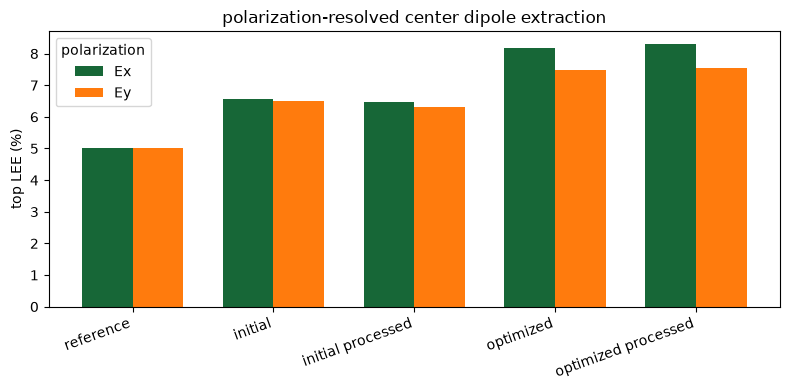

In [25]:
central_records = []

for key in central_data.keys():
    sim_data = central_data[key]
    design, polarization = key.split("-")
    central_records.append(
        summarize_lee_result(
            sim_data,
            design=design,
            polarization=polarization,
        )
    )

central_df = pd.DataFrame(central_records)
central_polarization_summary = (
    central_df.pivot_table(
        index="design",
        columns="polarization",
        values="top_lee",
        aggfunc="mean",
    )
    .loc[design_order, list(polarizations)]
)

fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)

x = np.arange(len(central_polarization_summary.index))
bar_width = 0.36
for offset_index, polarization in enumerate(polarizations):
    offset = (offset_index - 0.5 * (len(polarizations) - 1)) * bar_width
    ax.bar(
        x + offset,
        100 * central_polarization_summary[polarization],
        width=bar_width,
        label=polarization,
    )

ax.set_xticks(x)
ax.set_xticklabels(central_polarization_summary.index, rotation=20, ha="right")
ax.set_ylabel("top LEE (%)")
ax.set_title("polarization-resolved center dipole extraction")
ax.legend(title="polarization")

plt.show()


In [26]:
central_summary = (
    central_df.groupby("design")[["top_lee"]]
    .mean()
    .loc[design_order]
)

central_summary.round(4)


,top_lee
design,
reference,0.0501
initial,0.0653
initial processed,0.0640
optimized,0.0784
optimized processed,0.0791


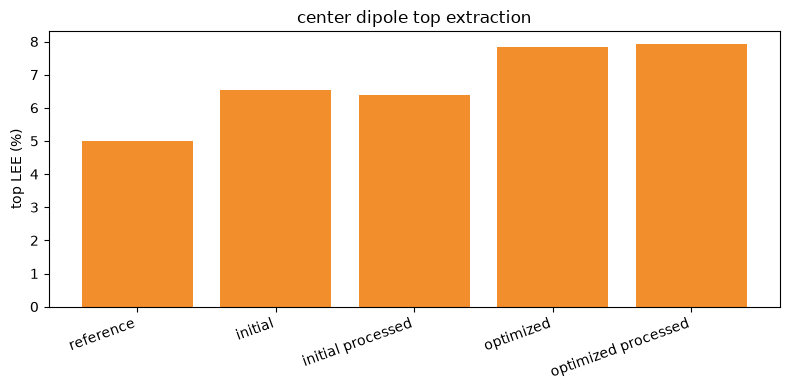

In [27]:
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)

x = np.arange(len(central_summary.index))
ax.bar(x, 100 * central_summary["top_lee"], color="#f28e2b")
ax.set_xticks(x)
ax.set_xticklabels(central_summary.index, rotation=20, ha="right")
ax.set_ylabel("top LEE (%)")
ax.set_title("center dipole top extraction")

plt.show()


### Dipole Position Average

Real LEDs emit from an active region rather than from one fixed dipole position. Here we sample a small lateral grid spanning one wavelength in the `x` and `y` directions and average top LEE over both position and in-plane polarization.

In [28]:
def build_lateral_source_positions(offset=center_wavelength):
    """Create a 3 by 3 lateral grid of dipole positions around the pixel center.

    Parameters
    ----------
    offset : float
        Distance in microns from the center position to the outer grid points along x and y.

    Returns
    -------
    list[tuple[float, float, float]]
        Source centers with fixed z coordinate and sampled lateral positions.
    """
    coords = np.array([-offset, 0.0, offset])
    return [
        (float(x_pos), float(y_pos), source_center[2])
        for y_pos in coords
        for x_pos in coords
    ]


source_positions = build_lateral_source_positions()
source_position_labels = [str(index) for index in range(len(source_positions))]
pd.DataFrame(
    [
        {"position_index": index, "x": position[0], "y": position[1], "z": position[2]}
        for index, position in enumerate(source_positions)
    ]
)


,position_index,x,y,z
0,0,-0.5,-0.5,-0.9
1,1,0.0,-0.5,-0.9
2,2,0.5,-0.5,-0.9
3,3,-0.5,0.0,-0.9
4,4,0.0,0.0,-0.9
5,5,0.5,0.0,-0.9
6,6,-0.5,0.5,-0.9
7,7,0.0,0.5,-0.9
8,8,0.5,0.5,-0.9


In [32]:
position_sims = {}

for position_index, position in enumerate(source_positions):
    for design, design_spec in analysis_designs.items():
        for polarization in polarizations:
            key = f"{design}-pos{position_index}-{polarization}"
            position_sims[key] = build_analysis_simulation(
                design_spec["params"],
                source_center=position,
                source_polarization=polarization,
                grid_spec=analysis_grid_spec,
                etch_geometry=design_spec["etch_geometry"],
            )

    for polarization in polarizations:
        key = f"reference-pos{position_index}-{polarization}"
        position_sims[key] = build_interface_reference_simulation(
            source_center=position,
            source_polarization=polarization,
            grid_spec=analysis_grid_spec,
        )

position_batch = web.Batch(
    simulations=position_sims,
    folder_name="Autograd32ClipOperationPositionLEE",
)
position_batch.estimate_cost();

position_data = position_batch.run(path_dir="data/Autograd32ClipOperationPositionLEE")

09:33:37 EDT Maximum FlexCredit cost: 343.417 for the whole batch.

             Got 10 simulations from cache.

Output()

09:34:16 EDT Started working on Batch containing 90 tasks.

09:36:21 EDT Maximum FlexCredit cost: 343.417 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

09:54:10 EDT Batch complete.

In [33]:
position_records = []

for key in position_data.keys():
    sim_data = position_data[key]
    design, position_tag, polarization = key.split("-")
    position_index = int(position_tag.replace("pos", ""))
    position_records.append(
        summarize_lee_result(
            sim_data,
            design=design,
            polarization=polarization,
            position_index=position_index,
            source_center=source_positions[position_index],
        )
    )

position_df = pd.DataFrame(position_records)


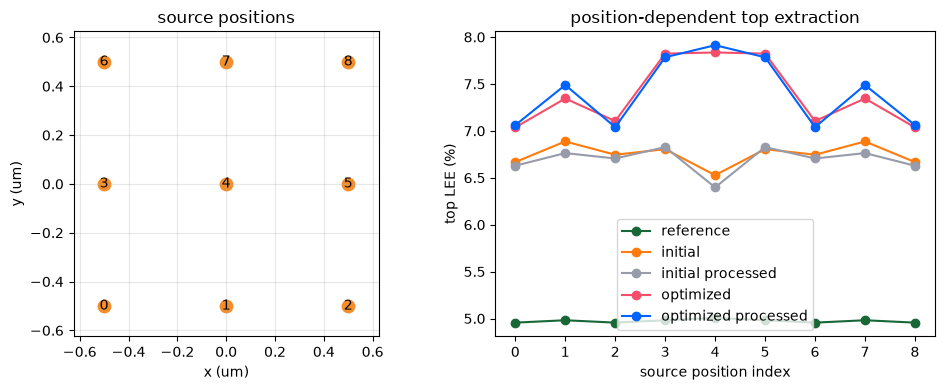

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

source_xy = np.array([(position[0], position[1]) for position in source_positions])
ax[0].scatter(source_xy[:, 0], source_xy[:, 1], s=80, color="#f28e2b")
for index, (x_pos, y_pos) in enumerate(source_xy):
    ax[0].text(x_pos, y_pos, source_position_labels[index], ha="center", va="center")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title("source positions")
ax[0].set_aspect("equal")
ax[0].set_xlim(-1.25 * center_wavelength, 1.25 * center_wavelength)
ax[0].set_ylim(-1.25 * center_wavelength, 1.25 * center_wavelength)
ax[0].grid(True, alpha=0.3)

for design in design_order:
    subset = position_df[position_df["design"] == design]
    grouped = subset.groupby("position_index")["top_lee"].mean()
    ax[1].plot(grouped.index, 100 * grouped.values, "o-", label=design)

ax[1].set_xlabel("source position index")
ax[1].set_ylabel("top LEE (%)")
ax[1].set_title("position-dependent top extraction")
ax[1].set_xticks(range(len(source_positions)))
ax[1].legend()

plt.show()


## Summary

This example used `ClipOperation` geometry to build a compact micro-LED surface texture from two intersecting hexagonal hole lattices. The design parameters flowed through the boolean geometry, the Tidy3D remote adjoint solve, and the scalar top-flux objective into a Tidy3D Adam optimization loop.

The final analysis used independent flux monitors to normalize the upward extracted power by the emitted dipole power. It compared the raw and fabrication-processed initial and optimized designs against a flat-interface reference using top LEE, then averaged over in-plane dipole polarizations and lateral source positions. The final non-adjoint evaluations were run at twice the mesh resolution used during optimization after small-feature cleanup was applied.
